# Skin Disease Classification (VGG19)

### **Colab / Local Environment Setup**
This notebook auto-detects the environment and configures paths accordingly.

- **Google Colab**: Upload your `train` and `test` folders to your Google Drive under `My Drive/Grad proj/`, then the notebook will mount Drive automatically.
- **Local (Windows)**: Ensure your `train` and `test` folders are at `D:\Grad proj\train` and `D:\Grad proj\test`, OR in the same directory as this notebook.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input # Updated for EfficientNetV2
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)

## 1. Environment Detection & Path Setup

In [2]:
# ============================================================
# ENVIRONMENT DETECTION - works on Colab, Local Windows, Linux
# ============================================================

TRAIN_DIR = None
TEST_DIR = None

# --- Option 1: Google Colab ---
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Check if data is already at /content/train (e.g. uploaded directly)
    if os.path.exists('/content/train'):
        TRAIN_DIR = '/content/train'
        TEST_DIR = '/content/test'
        print('[INFO] Running on Colab - data found at /content/train')
    else:
        # Skip mounting Google Drive as data is expected to come from Kaggle download
        print('[INFO] Skipping Google Drive mount as Kaggle data is used.')

# --- Option 2: Local Windows ---
if TRAIN_DIR is None and os.path.exists(r'D:\Grad proj\train'):
    TRAIN_DIR = r'D:\Grad proj\train'
    TEST_DIR = r'D:\Grad proj\test'
    print('[INFO] Running on Local Windows Environment')

# --- Option 3: Relative to current working directory ---
if TRAIN_DIR is None:
    cwd_train = os.path.join(os.getcwd(), 'train')
    if os.path.exists(cwd_train):
        TRAIN_DIR = cwd_train
        TEST_DIR = os.path.join(os.getcwd(), 'test')
        print(f'[INFO] Found data relative to working directory: {os.getcwd()}')

# --- Option 4: Relative path (last resort) ---
if TRAIN_DIR is None:
    if os.path.exists('train'):
        TRAIN_DIR = 'train'
        TEST_DIR = 'test'
        print('[INFO] Using relative train/test paths')

# The final check for FileNotFoundError is removed here.
# TRAIN_DIR and TEST_DIR will be set by the Kaggle download step (cell 921ad634).

# print(f'\nTrain Dir: {TRAIN_DIR}') # These lines will now execute after Kaggle download
# print(f'Test Dir:  {TEST_DIR}')   # in cell 921ad634.
# if TRAIN_DIR and os.path.exists(TRAIN_DIR):
#     print(f'Train folders: {len(os.listdir(TRAIN_DIR))}')
# else:
#     print('Train directory not yet set or found.')
# if TEST_DIR and os.path.exists(TEST_DIR):
#     print(f'Test folders:  {len(os.listdir(TEST_DIR))}')
# else:
#     print('Test directory not yet set or found.')

[INFO] Skipping Google Drive mount as Kaggle data is used.


## Resources

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shubhamgoel27/dermnet")

print("Path to dataset files:", path)

100%|██████████| 1.72G/1.72G [00:44<00:00, 41.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shubhamgoel27/dermnet/versions/1


### Update Data Directories to use Kaggle Dataset

Now that the Kaggle dataset is downloaded, we will update the `TRAIN_DIR` and `TEST_DIR` variables to point to the `train` and `test` subdirectories within the downloaded path. This ensures that subsequent data loading and processing steps use the Kaggle data.

In [4]:
import os

# Assuming the downloaded dataset has 'train' and 'test' subdirectories
TRAIN_DIR = os.path.join(path, 'train')
TEST_DIR = os.path.join(path, 'test')

print(f'Updated Train Dir: {TRAIN_DIR}')
print(f'Updated Test Dir:  {TEST_DIR}')

# Verify if the directories exist
if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"Train directory not found at {TRAIN_DIR}")
if not os.path.exists(TEST_DIR):
    raise FileNotFoundError(f"Test directory not found at {TEST_DIR}")

print(f'Train folders: {len(os.listdir(TRAIN_DIR))}')
print(f'Test folders:  {len(os.listdir(TEST_DIR))}')

Updated Train Dir: /root/.cache/kagglehub/datasets/shubhamgoel27/dermnet/versions/1/train
Updated Test Dir:  /root/.cache/kagglehub/datasets/shubhamgoel27/dermnet/versions/1/test
Train folders: 23
Test folders:  23


## 2. Robust Data Indexing

In [5]:
FOLDER_MAP = {
    'Acne': ['Acne and Rosacea Photos'],
    'Eczema': ['Eczema Photos', 'Atopic Dermatitis Photos'],
    'Psoriasis': ['Psoriasis pictures Lichen Planus and related diseases'],
    'Fungal': ['Tinea Ringworm Candidiasis and other Fungal Infections'],
    'Melanoma': ['Melanoma Skin Cancer Nevi and Moles'],
    'Vitiligo': ['Light Diseases and Disorders of Pigmentation']
}

def build_df(base_dir, mapping):
    data = []
    found_on_disk = os.listdir(base_dir)

    for label, folders in mapping.items():
        for folder in folders:
            # Try case-insensitive matching for Linux/Colab robustness
            match = next((f for f in found_on_disk if f.lower() == folder.lower()), None)

            if match:
                path = os.path.join(base_dir, match)
                imgs = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                if imgs:
                    print(f"  [LOADED] {label}: {len(imgs)} images from '{match}'")
                    for img in imgs:
                        data.append({'filename': os.path.join(match, img), 'class': label})
            else:
                print(f"  [MISSING] {folder}")

    return pd.DataFrame(data, columns=['filename', 'class'])

print("Indexing images...")
df_train_full = build_df(TRAIN_DIR, FOLDER_MAP)
df_test = build_df(TEST_DIR, FOLDER_MAP)

if df_train_full.empty:
    print("\nAvailable Folders in Train Dir:", os.listdir(TRAIN_DIR))
    raise ValueError("No images found. Check folder names against the list above.")

# Split 80/20
df_train, df_val = train_test_split(df_train_full, test_size=0.2, stratify=df_train_full['class'], random_state=42)
print(f"\nDataset Stats: Train={len(df_train)}, Val={len(df_val)}, Test={len(df_test)}")

Indexing images...
  [LOADED] Acne: 840 images from 'Acne and Rosacea Photos'
  [LOADED] Eczema: 1235 images from 'Eczema Photos'
  [LOADED] Eczema: 489 images from 'Atopic Dermatitis Photos'
  [LOADED] Psoriasis: 1405 images from 'Psoriasis pictures Lichen Planus and related diseases'
  [LOADED] Fungal: 1300 images from 'Tinea Ringworm Candidiasis and other Fungal Infections'
  [LOADED] Melanoma: 463 images from 'Melanoma Skin Cancer Nevi and Moles'
  [LOADED] Vitiligo: 568 images from 'Light Diseases and Disorders of Pigmentation'
  [LOADED] Acne: 312 images from 'Acne and Rosacea Photos'
  [LOADED] Eczema: 309 images from 'Eczema Photos'
  [LOADED] Eczema: 123 images from 'Atopic Dermatitis Photos'
  [LOADED] Psoriasis: 352 images from 'Psoriasis pictures Lichen Planus and related diseases'
  [LOADED] Fungal: 325 images from 'Tinea Ringworm Candidiasis and other Fungal Infections'
  [LOADED] Melanoma: 116 images from 'Melanoma Skin Cancer Nevi and Moles'
  [LOADED] Vitiligo: 143 ima

## 4. Exploratory Data Analysis (EDA)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Define class names here as it's needed for EDA before model training
class_names = sorted(df_train_full['class'].unique())
print(f"Detected Classes: {class_names}")

Detected Classes: ['Acne', 'Eczema', 'Fungal', 'Melanoma', 'Psoriasis', 'Vitiligo']


### Class Distribution

/tmp/ipykernel_3365/1510794164.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='class', data=df_train_full, order=class_names, palette='viridis')
/tmp/ipykernel_3365/1510794164.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='class', data=df_train, order=class_names, palette='viridis')
/tmp/ipykernel_3365/1510794164.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='class', data=df_val, order=class_names, palette='viridis')
/tmp/ipykernel_3365/1510794164.py:23: FutureWarning: 

Passing `palette` without assigning `hue

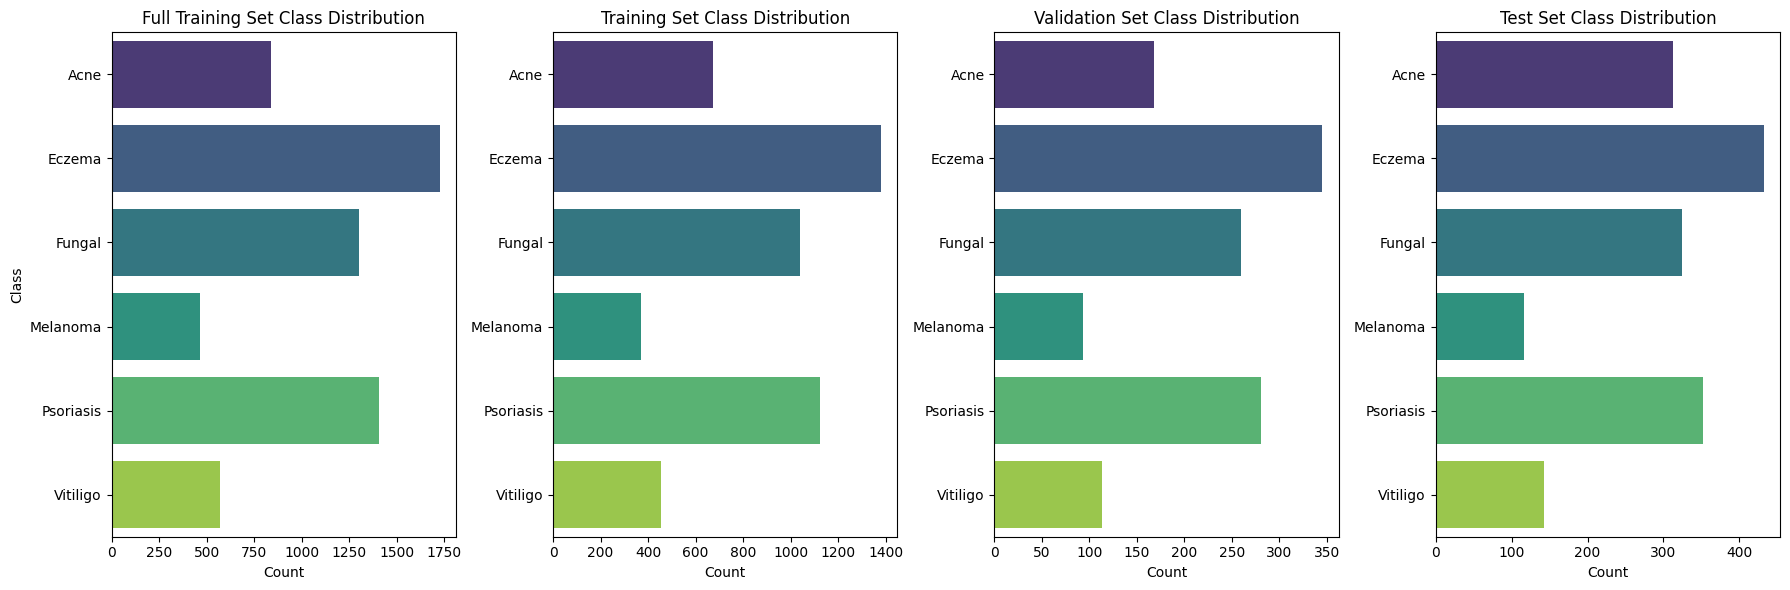

In [7]:
# Plot class distribution for full training, training, validation, and test sets
plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
sns.countplot(y='class', data=df_train_full, order=class_names, palette='viridis')
plt.title('Full Training Set Class Distribution')
plt.xlabel('Count')
plt.ylabel('Class')

plt.subplot(1, 4, 2)
sns.countplot(y='class', data=df_train, order=class_names, palette='viridis')
plt.title('Training Set Class Distribution')
plt.xlabel('Count')
plt.ylabel('')

plt.subplot(1, 4, 3)
sns.countplot(y='class', data=df_val, order=class_names, palette='viridis')
plt.title('Validation Set Class Distribution')
plt.xlabel('Count')
plt.ylabel('')

plt.subplot(1, 4, 4)
sns.countplot(y='class', data=df_test, order=class_names, palette='viridis')
plt.title('Test Set Class Distribution')
plt.xlabel('Count')
plt.ylabel('')

plt.tight_layout()
plt.show()

### Sample Images per Class

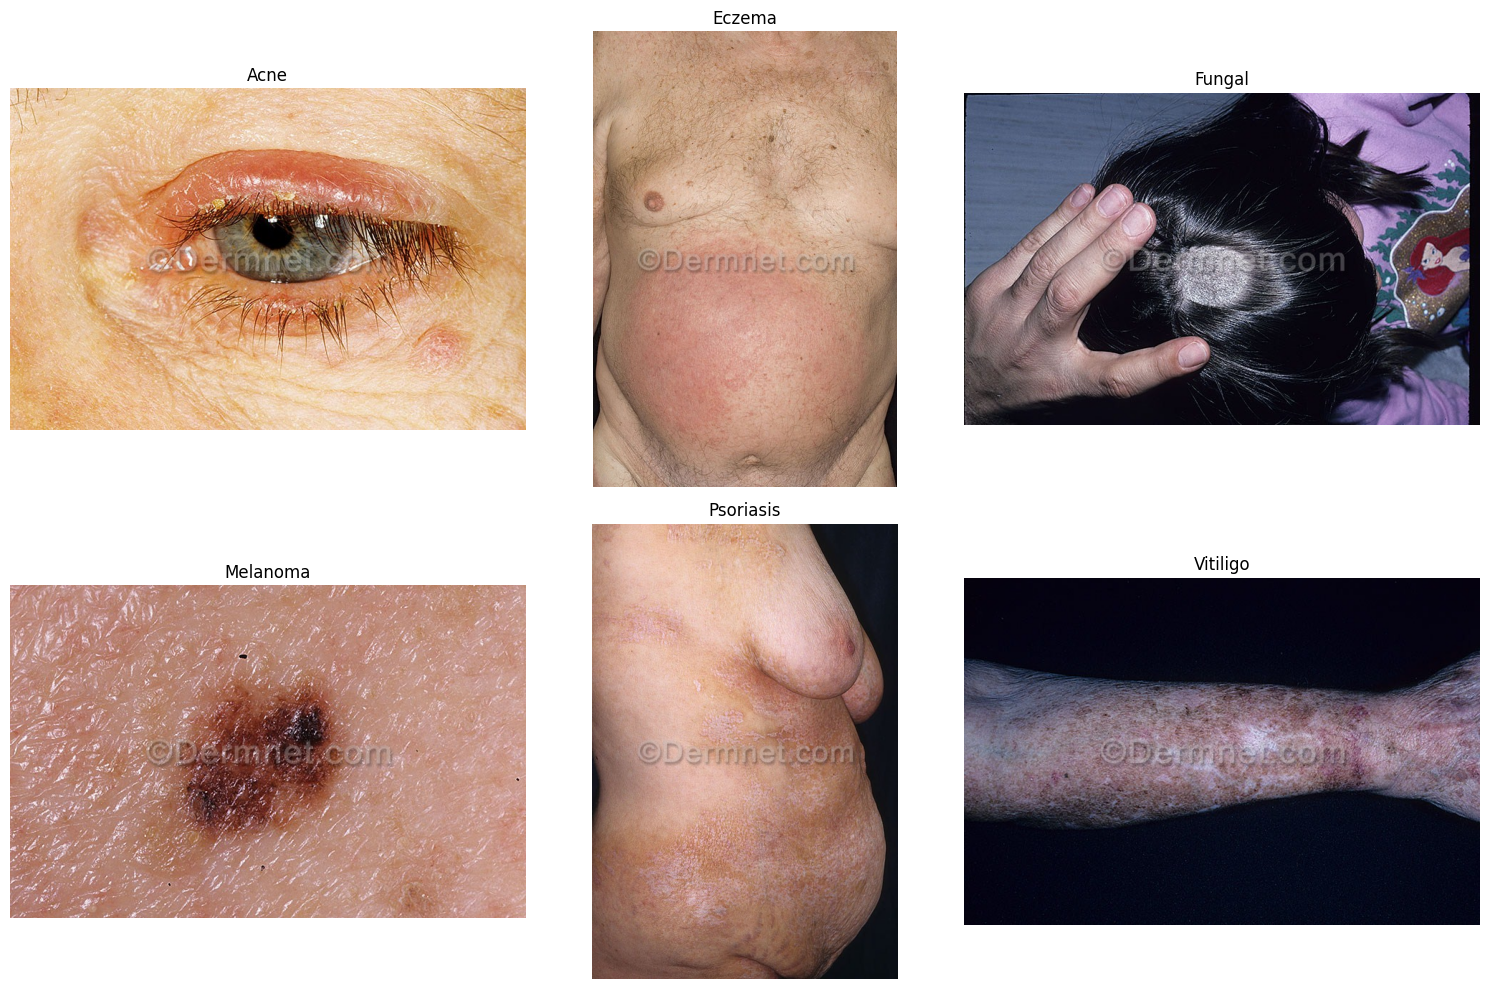

In [8]:
# Display a sample image for each class
plt.figure(figsize=(15, 10))
for i, class_name in enumerate(class_names):
    plt.subplot(2, 3, i + 1)
    # Get a random image path for the current class from the training set
    sample_img_path = df_train[df_train['class'] == class_name].sample(1)['filename'].iloc[0]
    full_img_path = os.path.join(TRAIN_DIR, sample_img_path)
    img = Image.open(full_img_path)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.tight_layout()
plt.show()

### Interpreting Class Distribution

From the generated plots, it's evident that there's a significant class imbalance across the dataset. Some classes like 'Eczema' and 'Fungal' have a much larger number of samples compared to 'Melanoma' and 'Vitiligo'. This imbalance is consistent across the full training, training, validation, and test sets.

This is a critical observation, as imbalanced datasets can lead to models that perform well on majority classes but poorly on minority classes. The model might become biased towards the more frequent classes, resulting in lower recall and F1-scores for the under-represented diseases.

### Quantifying Class Imbalance

To better understand the extent of this imbalance, let's calculate the exact counts and percentages for each class in the full training dataset.

In [9]:
print('Class Distribution in Full Training Set:')
class_counts = df_train_full['class'].value_counts()
class_percentages = df_train_full['class'].value_counts(normalize=True) * 100

class_distribution_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages
}).sort_values(by='Count', ascending=False)

display(class_distribution_df)


Class Distribution in Full Training Set:


,Count,Percentage
class,,
Eczema,1724,27.365079
Psoriasis,1405,22.301587
Fungal,1300,20.634921
Acne,840,13.333333
Vitiligo,568,9.015873
Melanoma,463,7.349206


### Dataset Problems and Solutions

**Identified Problem: Class Imbalance**

The numerical breakdown clearly shows that 'Psoriasis', 'Eczema', and 'Fungal' are the majority classes, while 'Melanoma' and 'Vitiligo' are significantly under-represented. This imbalance can severely impact the model's ability to accurately predict minority classes.

**Potential Solutions:**

1.  **Resampling Techniques:**
    *   **Oversampling minority classes:** Duplicating samples from minority classes (e.g., using `ImageDataGenerator`'s `rotation_range`, `zoom_range` to create new variations, or techniques like SMOTE).
    *   **Undersampling majority classes:** Randomly removing samples from majority classes (use with caution to avoid losing valuable information).
2.  **Class Weighting:** As already implemented, assigning higher weights to minority classes during training helps the model pay more attention to their errors. This was done using `compute_class_weight`.
3.  **Data Augmentation:** While already in use, more aggressive augmentation for minority classes can help create more diverse samples.
4.  **Evaluation Metrics:** Focus on metrics like F1-score, precision, recall, and AUC-ROC, especially per-class, rather than just overall accuracy, as accuracy can be misleading on imbalanced datasets.

## 3. Training & Architecture

In [10]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 1. Generators - using EfficientNetV2 preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.25,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.15,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(df_train, directory=TRAIN_DIR, x_col='filename', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_test_datagen.flow_from_dataframe(df_val, directory=TRAIN_DIR, x_col='filename', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen = val_test_datagen.flow_from_dataframe(df_test, directory=TEST_DIR, x_col='filename', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# 2. Class Weights
class_names = np.array(sorted(df_train['class'].unique()))
weights = compute_class_weight(class_weight='balanced', classes=class_names, y=df_train['class'])
weight_dict = dict(enumerate(weights))

# 3. Model Architecture (Switch to EfficientNetV2B0)
base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
out = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=out)

# 4. Callbacks
callbacks = [
    ModelCheckpoint('best_skin_model_effnet.h5', save_best_only=True, monitor='val_loss'),
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

print("\n--- Training Phase 1: Warmup (Head only) ---")
model.compile(optimizer=Adam(1e-3), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
model.fit(train_gen, validation_data=val_gen, epochs=15, class_weight=weight_dict, callbacks=callbacks)

print("\n--- Training Phase 2: Top-down Unfreezing ---")
base_model.trainable = True
# Freeze the bottom half (approx first 100 layers)
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=Adam(1e-4), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
model.fit(train_gen, validation_data=val_gen, epochs=15, class_weight=weight_dict, callbacks=callbacks)

print("\n--- Training Phase 3: Deep Fine-tuning ---")
base_model.trainable = True # Unfreeze everything
model.compile(optimizer=Adam(1e-5), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
model.fit(train_gen, validation_data=val_gen, epochs=20, class_weight=weight_dict, callbacks=callbacks)

Found 5040 validated image filenames belonging to 6 classes.
Found 1260 validated image filenames belonging to 6 classes.
Found 1680 validated image filenames belonging to 6 classes.
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

--- Training Phase 1: Warmup (Head only) ---
Epoch 1/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.2532 - loss: 2.2725

158/158 ━━━━━━━━━━━━━━━━━━━━ 155s 770ms/step - accuracy: 0.2881 - loss: 2.1090 - val_accuracy: 0.4230 - val_loss: 1.5202 - learning_rate: 0.0010
Epoch 2/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.3652 - loss: 1.7900

158/158 ━━━━━━━━━━━━━━━━━━━━ 87s 548ms/step - accuracy: 0.3756 - loss: 1.7848 - val_accuracy: 0.4849 - val_loss: 1.4326 - learning_rate: 0.0010
Epoch 3/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 85s 540ms/step - accuracy: 0.4073 - loss: 1.6262 - val_accuracy: 0.4865 - val_loss: 1.4494 - learning_rate: 0.0010
Epoch 4/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.4398 - loss: 1.5492

158/158 ━━━━━━━━━━━━━━━━━━━━ 86s 547ms/step - accuracy: 0.4365 - loss: 1.5502 - val_accuracy: 0.5103 - val_loss: 1.4080 - learning_rate: 0.0010
Epoch 5/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.4425 - loss: 1.5129

158/158 ━━━━━━━━━━━━━━━━━━━━ 86s 542ms/step - accuracy: 0.4421 - loss: 1.5210 - val_accuracy: 0.5222 - val_loss: 1.3750 - learning_rate: 0.0010
Epoch 6/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 86s 539ms/step - accuracy: 0.4540 - loss: 1.4822 - val_accuracy: 0.5175 - val_loss: 1.3996 - learning_rate: 0.0010
Epoch 7/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 86s 543ms/step - accuracy: 0.4623 - loss: 1.4588 - val_accuracy: 0.5262 - val_loss: 1.3824 - learning_rate: 0.0010
Epoch 8/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 86s 541ms/step - accuracy: 0.4641 - loss: 1.4548 - val_accuracy: 0.5087 - val_loss: 1.3824 - learning_rate: 0.0010
Epoch 9/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.4829 - loss: 1.4285

...

158/158 ━━━━━━━━━━━━━━━━━━━━ 91s 573ms/step - accuracy: 0.8359 - loss: 0.7525 - val_accuracy: 0.7373 - val_loss: 1.0395 - learning_rate: 1.0000e-05
Epoch 5/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 88s 560ms/step - accuracy: 0.8353 - loss: 0.7571 - val_accuracy: 0.7349 - val_loss: 1.0446 - learning_rate: 1.0000e-05
Epoch 6/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.8488 - loss: 0.7406

158/158 ━━━━━━━━━━━━━━━━━━━━ 89s 565ms/step - accuracy: 0.8484 - loss: 0.7449 - val_accuracy: 0.7302 - val_loss: 1.0357 - learning_rate: 1.0000e-05
Epoch 7/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.8395 - loss: 0.7597

158/158 ━━━━━━━━━━━━━━━━━━━━ 90s 570ms/step - accuracy: 0.8389 - loss: 0.7549 - val_accuracy: 0.7341 - val_loss: 1.0308 - learning_rate: 1.0000e-05
Epoch 8/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 89s 559ms/step - accuracy: 0.8438 - loss: 0.7439 - val_accuracy: 0.7341 - val_loss: 1.0332 - learning_rate: 1.0000e-05
Epoch 9/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 89s 558ms/step - accuracy: 0.8437 - loss: 0.7412 - val_accuracy: 0.7317 - val_loss: 1.0369 - learning_rate: 1.0000e-05
Epoch 10/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.8554 - loss: 0.7412

158/158 ━━━━━━━━━━━━━━━━━━━━ 97s 610ms/step - accuracy: 0.8454 - loss: 0.7457 - val_accuracy: 0.7373 - val_loss: 1.0298 - learning_rate: 1.0000e-05
Epoch 11/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 90s 570ms/step - accuracy: 0.8504 - loss: 0.7309 - val_accuracy: 0.7421 - val_loss: 1.0398 - learning_rate: 1.0000e-05
Epoch 12/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 90s 570ms/step - accuracy: 0.8498 - loss: 0.7313 - val_accuracy: 0.7413 - val_loss: 1.0424 - learning_rate: 1.0000e-05
Epoch 13/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 90s 568ms/step - accuracy: 0.8504 - loss: 0.7299 - val_accuracy: 0.7365 - val_loss: 1.0422 - learning_rate: 1.0000e-05
Epoch 14/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 89s 566ms/step - accuracy: 0.8591 - loss: 0.7235 - val_accuracy: 0.7341 - val_loss: 1.0319 - learning_rate: 5.0000e-06
Epoch 15/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.8615 - loss: 0.7303

158/158 ━━━━━━━━━━━━━━━━━━━━ 90s 567ms/step - accuracy: 0.8518 - loss: 0.7348 - val_accuracy: 0.7413 - val_loss: 1.0296 - learning_rate: 5.0000e-06
Epoch 16/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 88s 558ms/step - accuracy: 0.8538 - loss: 0.7205 - val_accuracy: 0.7365 - val_loss: 1.0345 - learning_rate: 5.0000e-06
Epoch 17/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 88s 557ms/step - accuracy: 0.8534 - loss: 0.7254 - val_accuracy: 0.7349 - val_loss: 1.0342 - learning_rate: 5.0000e-06
Epoch 18/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 89s 564ms/step - accuracy: 0.8627 - loss: 0.7134 - val_accuracy: 0.7349 - val_loss: 1.0327 - learning_rate: 5.0000e-06
Epoch 19/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 88s 556ms/step - accuracy: 0.8552 - loss: 0.7200 - val_accuracy: 0.7381 - val_loss: 1.0377 - learning_rate: 2.5000e-06
Epoch 20/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 88s 560ms/step - accuracy: 0.8692 - loss: 0.7064 - val_accuracy: 0.7452 - val_loss: 1.0364 - learning_rate: 2.5000e-06


## 4. Evaluation

53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 267ms/step

Classification Report:
              precision    recall  f1-score   support

        Acne       0.84      0.91      0.88       312
      Eczema       0.72      0.71      0.72       432
      Fungal       0.67      0.75      0.71       325
    Melanoma       0.75      0.84      0.79       116
   Psoriasis       0.75      0.58      0.65       352
    Vitiligo       0.59      0.61      0.60       143

    accuracy                           0.73      1680
   macro avg       0.72      0.73      0.73      1680
weighted avg       0.73      0.73      0.73      1680



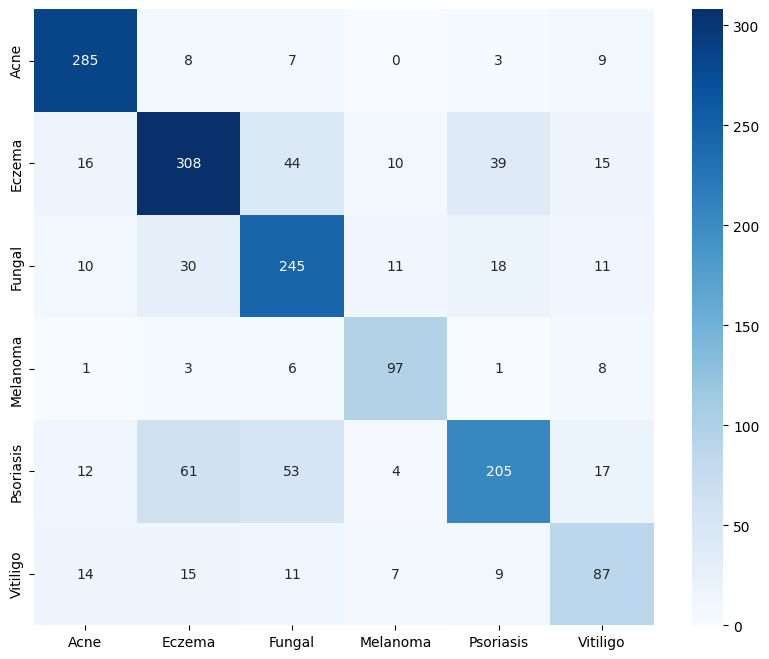

In [11]:
Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.show()

## 5. Test-Time Augmentation (TTA)

In [12]:
print("\n--- Performing Test-Time Augmentation (TTA) ---")

# Create a new ImageDataGenerator for TTA with similar augmentations as training
tta_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.25,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.15,
    fill_mode='nearest'
)

# Number of TTA passes
TTA_STEPS = 7

# Accumulate predictions
tta_predictions = []

for i in range(TTA_STEPS):
    print(f"TTA Pass {i+1}/{TTA_STEPS}")
    # For TTA, we generate new augmented images from the test set for each pass
    tta_gen = tta_datagen.flow_from_dataframe(
        df_test,
        directory=TEST_DIR,
        x_col='filename',
        y_col='class',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False # Crucial for TTA to ensure samples are in the same order
    )
    tta_predictions.append(model.predict(tta_gen))

# Average the softmax outputs
averaged_predictions = np.mean(tta_predictions, axis=0)
tta_y_pred = np.argmax(averaged_predictions, axis=1)

print("\n--- Classification Report (Original) ---")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\n--- Classification Report (with TTA) ---")
print(classification_report(y_true, tta_y_pred, target_names=class_names))

# You can also visualize a confusion matrix for TTA if desired
# tta_cm = confusion_matrix(y_true, tta_y_pred)
# plt.figure(figsize=(10, 8))
# sns.heatmap(tta_cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
# plt.title('Confusion Matrix with TTA')
# plt.show()


--- Performing Test-Time Augmentation (TTA) ---
TTA Pass 1/7
Found 1680 validated image filenames belonging to 6 classes.
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 499ms/step
TTA Pass 2/7
Found 1680 validated image filenames belonging to 6 classes.
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 503ms/step
TTA Pass 3/7
Found 1680 validated image filenames belonging to 6 classes.
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 514ms/step
TTA Pass 4/7
Found 1680 validated image filenames belonging to 6 classes.
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 501ms/step
TTA Pass 5/7
Found 1680 validated image filenames belonging to 6 classes.
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 497ms/step
TTA Pass 6/7
Found 1680 validated image filenames belonging to 6 classes.
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 503ms/step
TTA Pass 7/7
Found 1680 validated image filenames belonging to 6 classes.
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 509ms/step

--- Classification Report (Original) ---
              precision    recall  f1-score   support

        Acne       0.84      0.91      0.8

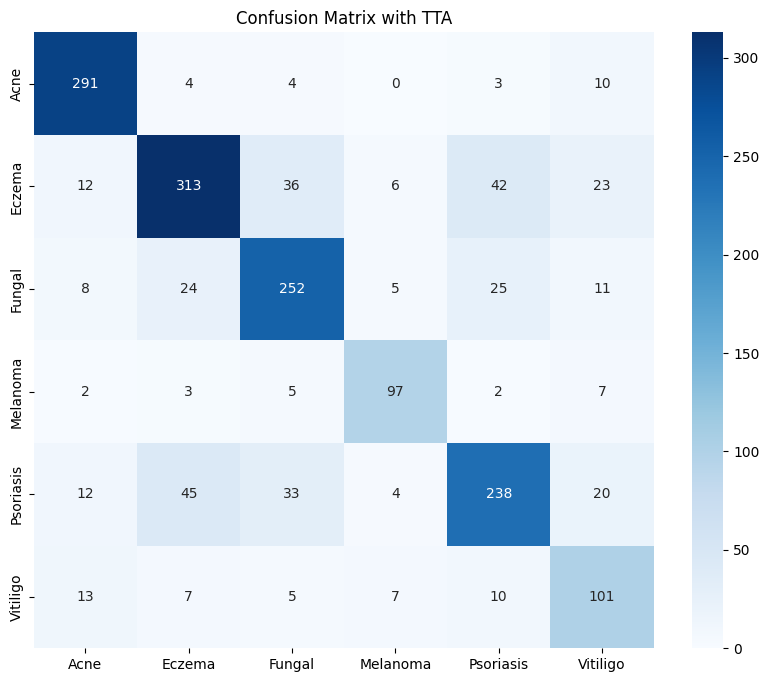

In [13]:
tta_cm = confusion_matrix(y_true, tta_y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(tta_cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix with TTA')
plt.show()

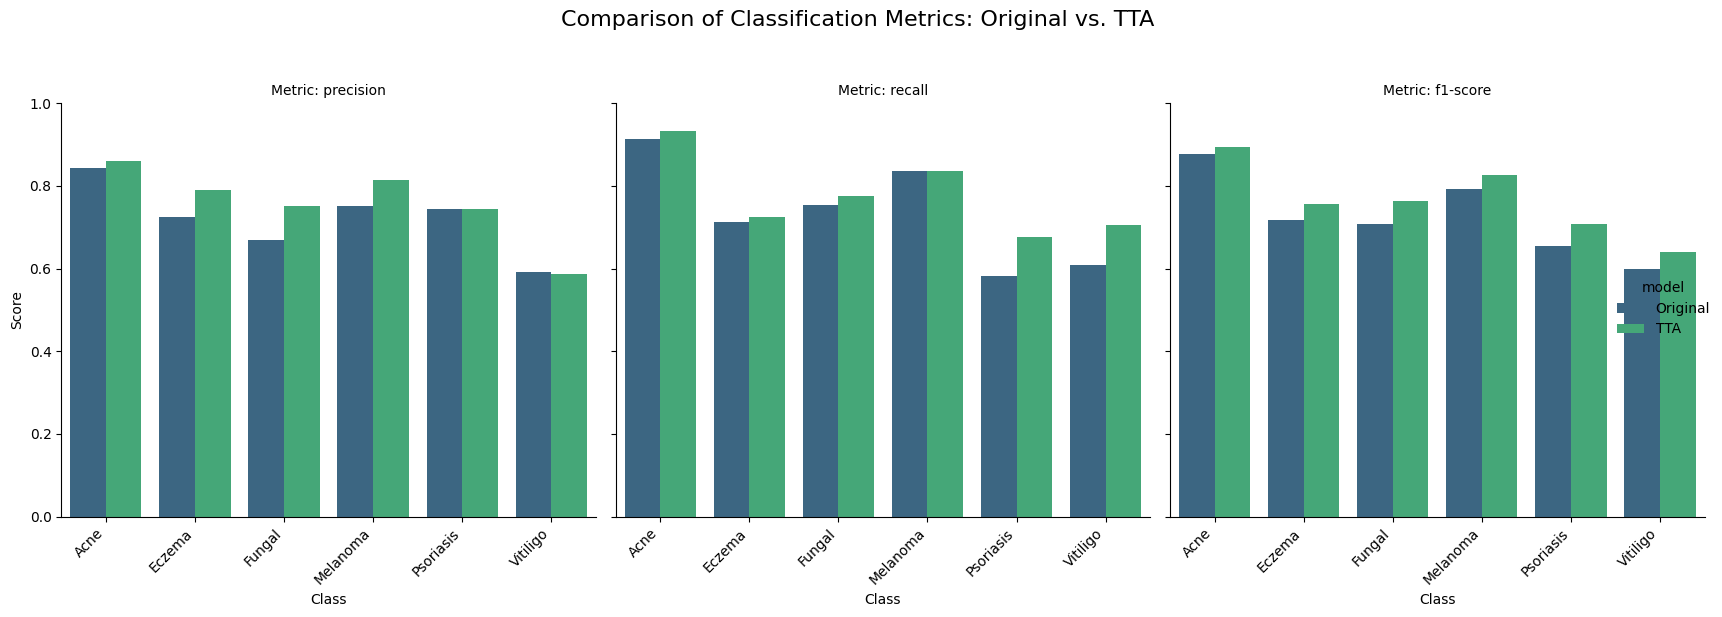

In [18]:
from sklearn.metrics import classification_report

# Get classification reports as dictionaries
report_original = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_tta = classification_report(y_true, tta_y_pred, target_names=class_names, output_dict=True)

# Convert to DataFrame, excluding 'accuracy', 'macro avg', 'weighted avg'
df_original = pd.DataFrame(report_original).transpose()
df_original = df_original.drop(labels=['accuracy', 'macro avg', 'weighted avg'])
df_original['model'] = 'Original'

df_tta = pd.DataFrame(report_tta).transpose()
df_tta = df_tta.drop(labels=['accuracy', 'macro avg', 'weighted avg'])
df_tta['model'] = 'TTA'

# Combine dataframes
df_combined = pd.concat([df_original, df_tta]).reset_index()
df_combined = df_combined.rename(columns={'index': 'class'})

# Melt the DataFrame for easier plotting of multiple metrics
df_melted = df_combined.melt(id_vars=['class', 'model'], value_vars=['precision', 'recall', 'f1-score'],
                             var_name='metric', value_name='score')

# Use sns.catplot to create separate plots for each metric
g = sns.catplot(x='class', y='score', hue='model', col='metric', data=df_melted, kind='bar', palette='viridis', height=6, aspect=0.9, legend=True)
g.set_axis_labels('Class', 'Score')
g.set_titles('Metric: {col_name}')
g.set_xticklabels(rotation=45, ha='right')
g.set(ylim=(0, 1)) # Metrics are between 0 and 1
g.fig.suptitle('Comparison of Classification Metrics: Original vs. TTA', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

## 6. Exporting the Model

In [14]:
# Install tf2onnx for Keras to ONNX conversion
!pip install -q tf2onnx
print("tf2onnx installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 98.1 MB/s eta 0:00:00
tf2onnx installed.


In [16]:
import tensorflow as tf
import tf2onnx
import onnx

# --- 1. Export to Keras native format (.keras) ---
keras_model_path = 'skin_disease_classifier.keras'
model.save(keras_model_path)
print(f"Model saved in native Keras format at: {keras_model_path}")

# --- 2. Export to ONNX format ---
onnx_model_path = 'skin_disease_classifier.onnx'

# Convert Keras model to ONNX
# The input signature is crucial for ONNX export. We use a fixed shape here.
spec = (tf.TensorSpec(model.inputs[0].shape, model.inputs[0].dtype, name="input"),)
onnx_model_proto, _ = tf2onnx.convert.from_keras(model, input_signature=spec, opset=13, output_path=onnx_model_path)

print(f"Model converted and saved in ONNX format at: {onnx_model_path}")

# Optional: Verify the ONNX model
try:
    onnx_model = onnx.load(onnx_model_path)
    onnx.checker.check_model(onnx_model)
    print("ONNX model check successful.")
except Exception as e:
    print(f"ONNX model check failed: {e}")

Model saved in native Keras format at: skin_disease_classifier.keras
Model converted and saved in ONNX format at: skin_disease_classifier.onnx
ONNX model check successful.
